# Neural Networks

Recall that a hypothesis function (i.e. a choice of architecture) $h\colon \mathbb{R}^d \to \mathbb{R}^K$ maps input data to desired outputs. Initially, we used a linear hypothesis class $h_\Theta(\mathbf{x}) = \Theta^\top \mathbf{x}$ where $\Theta \in \mathbb{R}^{d \times K}.$ This forms $K$ linear functions of the input and predicts the class with the largest value. This turns out to be equivalent to partitioning the input space into $K$ linear convex regions corresponding to each class. 


![](./img/03-1.svg){width=60%}

**Remark.** In $\mathbb{R}^2$ with $3$ classes, we have $2$ inequality constraints $\theta_1^\top \mathbf{x} \geq \theta_2^\top \mathbf{x}$ and $\theta_1^\top \mathbf{x} \geq \theta_3^\top \mathbf{x}.$ This resuts in a  convex polyhedron which is the intersection of two linear half-spaces. Similarly, for the other two. It can be shown that the interior of these subsets are disjoint and the union of the three cover all of $\mathbb{R}^2.$

**Q.** What about data that are not linearly separable? We want some way to separate these points via a nonlinear set of class boundaries.

In [1]:
import math
import numpy as np

N = 100
r_eps = 0.3

def circle_data(radius: float, r_eps=r_eps, num_points=N):
    r0 = radius
    t = 2 * math.pi * np.random.random(N)
    r = r0 + r_eps * np.random.randn(N)
    x, y = r * np.cos(t), r * np.sin(t)
    return x, y

x0, y0 = circle_data(3)
x1, y1 = circle_data(5)
x2, y2 = circle_data(1)

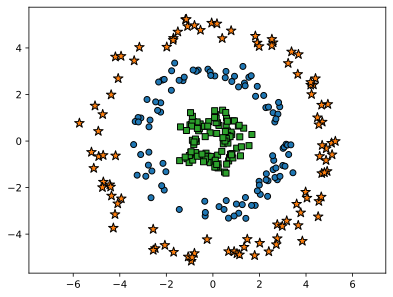

In [2]:
#| code-fold: true
%config InlineBackend.figure_formats = ["svg"] 
import matplotlib.pyplot as plt

plt.scatter(x0, y0, edgecolor="k")
plt.scatter(x1, y1, marker="*", edgecolor="k", s=100)
plt.scatter(x2, y2, marker="s", edgecolor="k")
plt.axis("equal");

## Nonlinear features

**One idea:** Apply a linear classifier to
some (potentially higher-dimensional) *features* of the data:

$$h_\Theta(\mathbf{x}) = \Theta^\top \phi(\mathbf{x})$$

where $\Theta \in \mathbb{R}^{h \times K}$ and $\phi\colon \mathbb{R}^d \to \mathbb{R}^h$ is a **feature transformation**. 

**Example.** For the above dataset, we can define $\phi(x, y) = (x, y, x^2 + y^2)$ (i.e. $r^2$) which makes the dataset separable in $\mathbb{R}^3$:

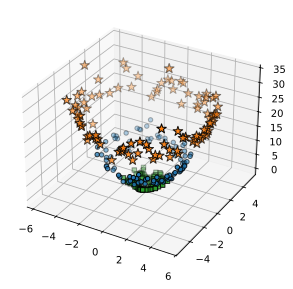

In [3]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x0, y0, x0 ** 2 + y0 ** 2, edgecolor="k")
ax.scatter(x1, y1, x1 ** 2 + y1 ** 2, marker="*", edgecolor="k", s=100)
ax.scatter(x2, y2, x2 ** 2 + y2 ** 2, marker="s", edgecolor="k");

**Q.** How do we create the features? 

1. Manual feature engineering (see above).
2. In a way that $\phi$ itself is **learned** from data (i.e. $\phi$ parametric).

Note that $\phi$ linear doesn't work since we just get a linear classifier. If $\phi(\mathbf{x}) = \Phi^\top \mathbf{x}$ where $\Phi \in \mathbb{R}^{d \times h}$, then $h_\Theta(\mathbf{x}) 
= \Theta^\top \phi(\mathbf{x}) = \Theta^\top \Phi^\top \mathbf{x} = (\Phi \Theta)^\top \mathbf{x}.$ Thus, $\phi$ must be nonlinear. It turns out that applying a univariate **nonlinear** function $\sigma\colon \mathbb{R} \to \mathbb{R}$ called an **activation function**[^act] suffices to create rich hypothesis classes (see @sec-univapprox). Hence, we set 

$$\phi(\mathbf{x}) = \sigma(\Phi^\top \mathbf{x}).$$

**Remark.** More precisely, we require $\sigma$ to have a good range of values and almost everywhere differentiability to be usable. Observe that we can feature transform features, i.e. compose feature transformations. This is the main idea behind  deep networks as we will see below.

[^act]: The term "activation" has roots in neuroscience where it represents the [action potential](https://en.wikipedia.org/wiki/Action_potential#/media/File:Action_potential.svg) firing in the cell.

## Neural networks

A **neural network**[^neural] refers to a particular type of hypothesis class, consisting of *multiple*, *parameterized* differentiable functions (a.k.a. "**layers**") composed together in any manner to form the output. Since neural networks involve composing a lot of functions (sometimes hundreds), it is usually referred to as **deep neural networks**, although there is really no requirement on depth beyond being not linear.

[^neural]: The term stems from biological inspiration, but at this point, literally any hypothesis function of the type above is referred to as a neural network. 



### Two-layer neural network

The simplest form of neural network is basically just the nonlinear features presented earlier:

$$
\begin{aligned}
h_\Theta(\mathbf{X}) = \sigma ( \mathbf{X} \mathbf{W_1}) \mathbf{W}_2 
\end{aligned}
$$

where $\Theta = \{ \mathbf{W}_1 \in \mathbb{R}^{d \times h}, \mathbf{W}_2 \in \mathbb{R}^{h \times K} \}$ are called the **trainable parameters** of the network and $\sigma\colon \mathbb{R} \to \mathbb{R}$ is the **activation function** that is applied elementwise to each vector. A commonly used one is **ReLU** defined as $\sigma(z) = \max(0, z)$:

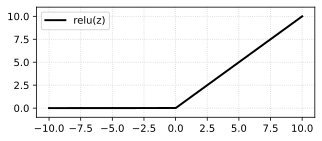

In [4]:
z = np.linspace(-10, 10, 1000)
plt.figure(figsize=(5, 2))
plt.plot(z, np.clip(z, a_min=0, a_max=None), label="relu(z)", linewidth=2, color="k")
plt.grid(alpha=0.6, linestyle="dotted"); plt.ylim(-1, 11); plt.legend();

### Fully-connected deep networks

Observe that for the 2-layer network, we have $|\Theta| = 2.$ A more generic form is the $L$-layer neural network, sometimes called a [multi-layer perceptron](https://en.wikipedia.org/wiki/Multilayer_perceptron) (MLP), **feedforward network** (FFN), or **fully-connected network** (FC) written in batch form as:

$$
h_\Theta(\mathbf{X}) = \sigma(\sigma(\ldots \sigma(\mathbf{X}\mathbf{W}_1)\mathbf{W}_2 \ldots) \mathbf{W}_{L-1}) \mathbf{W}_L
$$

or

$$
\begin{aligned}
\mathbf{Z}_0 &= \mathbf{X} \\
\mathbf{Z}_{i} &= \sigma_i (\mathbf{Z}_{i-1} \mathbf{W}_i), \quad \forall i = 1, \ldots, L \\
h_\Theta(\mathbf{X}) &= \mathbf{Z}_{L}
\end{aligned}
$$

where $\mathbf{Z}_i \in \mathbb{R}^{N \times d_i}$ and $\mathbf{W}_i \in \mathbb{R}^{d_{i-1} \times d_{i}}$, $d_0 = d$ and $d_{L} = K$, and $\sigma_i: \mathbb{R} \to \mathbb{R}$ are applied elementwise. The weights of the network is given by $\Theta = \{ \mathbf{W}_1, \ldots, \mathbf{W}_L \}$, so that $|\Theta| = L.$ Also, we typically set $\sigma_L = \text{Id}$ for the **output layer**.

**Remark.** Again a bias term can be added. But in theoretical analysis we can just think there is an extra column containing ones to simplify the computation. The index $i = 1, \ldots, L$ corresponds to the number of layers applied to the input. In particular, the output layer is indexed $L$ since we apply $L$ transformations to the input indexed $0.$ 

**Example.** Shapes for a 3-layer neural network which classifies inputs in $\mathbb{R}^{16}$ into $10$ classes:

| $i$  | $d_{i-1}$ | $d_{i}$ | PyTorch object |
| :-- | :--: | :--: | :-- |
| 1 |   16  |  32   | `Linear(16, 32)` | 
|2 |   32    |64   | `Linear(32, 64)` |
|3|    64|    10|   `Linear(64, 10)` |

## Backpropagation

Recall that to train the linear function via softmax regression and SGD, we had to calculate the gradients across cross-entropy and the matrix product. For a deep neural network, we need to calculate the gradient for each $\mathbf{W}_i \in \Theta,$ i.e. across each layer $i = 1, 2, \ldots, L.$ Since the gradients are calculated from the loss to the inputs, this part of the computation is called **backward pass**. The algorithm for caching intermediate results and accumulating the gradients is collectively called **backpropagation** (BP) or simply "backprop".

The best way to understand and calculate backprop is to view neural nets as **computational graphs** with certain defined **operations** (e.g. entire layers, or lower-level tensor operations):

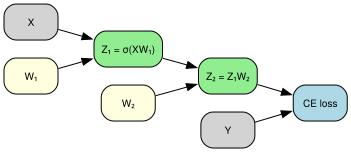

In [5]:
#| label: fig-network-dag
#| fig-cap: A computational graph of a two-layer neural network with softmax regression.
#| code-fold: true
from graphviz import Digraph

dot = Digraph(format="png")
dot.attr(rankdir="LR")
dot.node_attr.update(shape="box", style="rounded,filled", fontsize="10", fontname="Helvetica")
dot.node("X", "X", fillcolor="lightgray")
dot.node("W1", "W₁", fillcolor="lightyellow")
dot.node("Z1", "Z₁ = σ(XW₁)", fillcolor="lightgreen")
dot.node("W2", "W₂", fillcolor="lightyellow")
dot.node("Z2", "Z₂ = Z₁W₂", fillcolor="lightgreen")
dot.node("loss", "CE loss", fillcolor="lightblue")
dot.node("Y", "Y", fillcolor="lightgrey")

dot.edges([("X", "Z1"), ("W1", "Z1"), ("Z1", "Z2"), ("W2", "Z2"), ("Z2", "loss"), ("Y", "loss")])
dot

### Gradients of a 2-layer NN

Consider a 2-layer neural net for softmax regression. Our goal is to find $\nabla_{\mathbf{W}_i} \mathcal{L}(h_\Theta(\mathbf{X}), \mathbf{y})$ for $i = 1, 2.$ Write $\mathbf{Z}_1 = \sigma(\mathbf{X} \mathbf{W}_1)$ and $\mathbf{Z}_2 = \mathbf{Z_1}\mathbf{W}_2.$ First, we branch towards the linear dependencies of $\mathbf{Z}_2$:
net
$$
\boxed{
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial \mathbf{Z}_2} 
&= \frac{1}{B} (\hat{\mathbf{Y}} - \mathbf{Y}) \\[0.75em]
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_2}
&= 
\frac{\partial \mathcal{L}}{\partial \mathbf{Z}_2}
\frac{\partial \mathbf{Z}_2}{\partial \mathbf{W}_2}
=
\frac{1}{B}\mathbf{Z}_1^\top (\hat{\mathbf{Y}} - \mathbf{Y}) \\[0.75em]
\frac{\partial \mathcal{L}}{\partial \mathbf{Z}_1} &=
\frac{\partial \mathcal{L}}{\partial \mathbf{Z}_2}
\frac{\partial \mathbf{Z}_2}{\partial \mathbf{Z}_1} = 
\frac{1}{B}
(\hat{\mathbf{Y}} - \mathbf{Y})
\mathbf{W}_2^\top.
\end{aligned}
}
$$

For the second equation, the LHS has shape $(d_1, K)$, while the RHS has shape $(d_1, B) \times (B, K)$. The third equation is obtained by considering a single instance: ${\partial z_2^{j}}/{\partial z_1^{i}} = w^{ij}_2 = (w^\top_2)^{ji},$ giving the expected shape $(B, K) \times (K, d_1) = (B, d_1).$ 

Next, we calculate the gradient across $\sigma.$ We are taking the derivative of $d_1$ functions with respect to the weight tensor of shape $(d, d_1).$ Let $\mathbf{U}_1 = \mathbf{X}\mathbf{W}_1$, so that $\mathbf{Z}_1 = \sigma(\mathbf{U}_1).$ Then,

$$
\begin{align*}
\frac{\partial {z}_1^j}{\partial w_1^{ik}} 
&= \sum_l 
\frac{\partial z_1^j}{\partial u_1^l}
\frac{\partial u_1^l}{\partial w_1^{ik}}  \\
&= \sum_l \delta^{jl} \sigma^\prime(u_1^l) \, x^i \delta^{lk} = \delta^{jk} \sigma^\prime(u_1^j) \, x^i. 
\end{align*}
$$ {#eq-dzdw}

Here $\delta$ refers to the [Kronecker delta](https://en.wikipedia.org/wiki/Kronecker_delta). The two Kronecker deltas contract into one, and $\sigma^\prime(u^j)$ multiplies element-wise into the incoming gradient. The batch contributions are aggregated by multiplying $\mathbf{X}^\top.$ In batch form:

$$
\boxed{
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_1} 
&= \frac{\partial \mathcal{L}}{\partial \mathbf{Z}_1} \frac{\partial \mathbf{Z}_1}{\partial \mathbf{W}_1} \\[0.7em]
&= \mathbf{X}^\top \left( \frac{\partial \mathcal{L}}{\partial \mathbf{Z}_1} \odot \sigma^\prime(\mathbf{X} \mathbf{W}_1) \right) \\[0.7em]
&= \frac{1}{B} \mathbf{X}^\top \Big( [(\hat{\mathbf{Y}} - \mathbf{Y})
\mathbf{W}_2^\top ] \odot \sigma^\prime(\mathbf{X} \mathbf{W}_1) \Big).
\end{aligned}
}
$$


### Graph visualization

Backward dependence can be inspected using the `torchviz` library. The graph shows the forward tensors being stored ($\color{orange}\blacksquare$) during forward pass to compute the gradients. The weights ($\color{cyan}\blacksquare$) are instances of **leaf tensors**, i.e. the outermost nodes with no parent nodes. Hence, backward iteration stops at the leaf nodes. It follows that calculating gradients require:

- **twice** the memory of forward pass due to **caching**
- **same** time complexity $\mathcal{O}(S)$ where $S$ is the network size. 

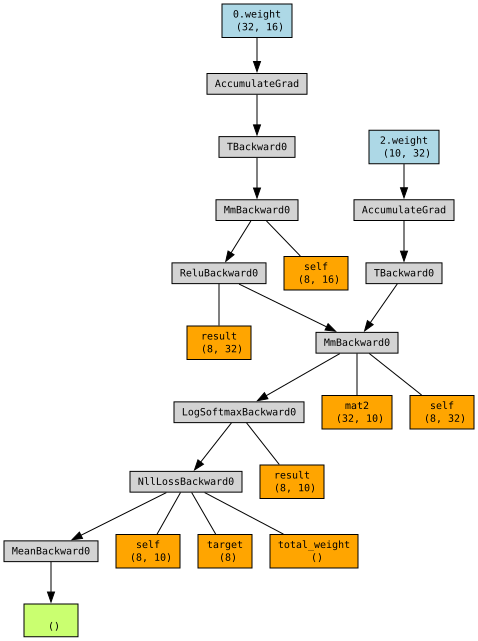

In [6]:
from torchviz import make_dot
import torch
import torch.nn as nn
import torch.nn.functional as F

model = nn.Sequential(
    nn.Linear(16, 32, bias=False),
    nn.ReLU(),
    nn.Linear(32, 10, bias=False)
)

B = 8
x = torch.randn(B, 16)
z = model(x)
y = torch.randint(0, 10, size=(B,))
loss = F.cross_entropy(z, y)

make_dot(loss.mean(), params=dict(model.named_parameters()), show_saved=True)

### General formula for $L$-layers

For an $L$-layer network, we can traverse along the $\mathbf{Z}_i$'s to find $\partial{\mathcal{L}} / \partial{\mathbf{Z_i}}$ by taking the product with the local gradients $\partial{\mathbf{Z}_{i}}/\partial{\mathbf{Z}_{i-1}}.$ This can be thought of as traversing the main trunk of the network (@fig-network-dag). Meanwhile, the gradient for the weights (leaf tensors) can be calculated using the incoming gradients and $\partial{\mathbf{Z}_{i}}/\partial{\mathbf{W}_{i}}$ (see @eq-dzdw). Calculating $\partial{\mathbf{Z}_{i}}/\partial{\mathbf{Z}_{i-1}}$ can be done similarly  as follows. Observe that indices check out:

$$
\begin{aligned}
\frac{\partial {z}_i^j}{\partial {z}_{i-1}^k} 
&= \sum_l 
\frac{\partial {z}_i^j}{\partial u_i^l}
\frac{\partial u_i^l}{\partial {z}_{i-1}^k}  \\
&= \sum_l \delta^{jl} \sigma^\prime(u_i^l) \, w_{i}^{kl} = \sigma^\prime(u_i^j) \, ({w^\top})^{jk}. 
\end{aligned}
$$ 

Let $\mathbf{G}_{i} = \frac{\partial{\mathcal{L}}}{\partial{\mathbf{Z}_{i}}}$ and $\boldsymbol{\varsigma}_i = \sigma_i^\prime(\mathbf{Z}_{i-1} \mathbf{W}_i)$ both of shape $(B, d_{i}).$ For $i = L, \ldots, 1$:

$$
\boxed{
\begin{aligned}
\mathbf{G}_{L} &= \frac{1}{B}(\hat{\mathbf{Y}} - \mathbf{Y}) \quad \quad \;\text{(cross-entropy)} \\
\mathbf{G}_{i-1} &= 
\mathbf{G}_{i} 
\frac{\partial \mathbf{Z}_{i}}{\partial \mathbf{Z}_{i-1}} 
= [\mathbf{G}_{i} \odot \boldsymbol{\varsigma}_i ]\mathbf{W}_i^\top \\
\frac{\partial \mathcal{L}}{\partial \mathbf{W}_{i}} 
&= \mathbf{G}_{i} 
\frac{\partial \mathbf{Z}_{i}}{\partial \mathbf{W}_{i}}
= \mathbf{Z}_{i-1}^\top[\mathbf{G}_{i} \odot \boldsymbol{\varsigma}_i]
\end{aligned}
}
$$

This looks very compact. You can verify that the shapes are correct and that it is consistent with the equations for a two-layer network with $\sigma_2 = \text{Id}.$ The formulas essentially describe the flow of gradients from the loss to the input. However, each update relies only on the gradients from the next layer.  

**Remark.** The gradients are modulated by $\sigma_i^\prime$ and then multiplied by the weights. This is analogous to forward pass, but involves only basic operations ($\odot$, MATMUL).
Also, the equations have the form `loss_grad x local_grad` where the loss gradient $\mathbf{G}_{i}$ from the next layer is, in a sense, "global" in contrast to the "local" gradients between adjacent nodes. This pattern is quite general as we will see in the next chapter. 

<!-- Finally, the shape checks out: $(B, d_{i}) \times (d_{i}, d_{i-1}) = (B, d_{i-1}).$ Here $\mathbf{W}_i^\top$ projects vectors in $\mathbb{R}^{d_{i}}$ to $\mathbb{R}^{d_{i-1}}.$ On the other hand, $\mathbf{Z}_{i-1}^\top$ accumulates $M$ vectors in $\mathbb{R}^{d_{i}}$ for each of the $d_{i-1}$ coordinates. -->

## Linearly separable features

An ideal classifier is that where the sequence of layers transform the input $\mathbf{x}_i \in \mathbb{R}^{d}$ into data points $F_{\Phi}(\mathbf{x}_i) \in \mathbb{R}^{d_{L-1}}$ that is linearly separable. That is, we essentially extend linear classification to input that is *not* linearly separable. This explains why the final layer has no activation, i.e. we can think of the network $f$ as

$$f_{(\Theta, \Phi)} = h_{\Theta} \circ F_{\Phi}$$

where $h_\Theta \colon \mathbb{R}^{d_{L-1}} \to \mathbb{R}^K$ is a linear hypothesis, while the earlier $L-1$ layers are feature extractors that compose $F_{\Phi}.$

**Demo.** Generating a dataset in $\mathbb{R}^2.$ Our goal is to separate this with a plane in $\mathbb{R}^3.$

In [7]:
import torch
torch.manual_seed(2)

def generate_data(M: int):
    noise = lambda e: torch.randn(M, 2) * e
    t = 2 * torch.pi * torch.rand(M, 1)
    s = 2 * torch.pi * torch.rand(M, 1)

    x0 = torch.cat([0.3 * torch.cos(s), 0.3 * torch.sin(s)], dim=1) + noise(0.2)
    x1 = torch.cat([3.0 * torch.cos(t), 3.0 * torch.sin(t)], dim=1) + noise(0.3)
    y0 = (torch.ones(M,) * 0).long()
    y1 = (torch.ones(M,) * 1).long()

    return x0, y0, x1, y1


x0, y0, x1, y1 = generate_data(1500)

Let's do a simple 2-layer neural net where the feature extractor maps to $\mathbb{R}^3$:

In [8]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 3), nn.Tanh(),
    nn.Linear(3, 2)
)

Model training:

In [9]:
import torch.nn.functional as F
from tqdm import tqdm

optim = torch.optim.SGD(model.parameters(), lr=0.01)

x = torch.cat([x0, x1])
y = torch.cat([y0, y1])
history = {"accs": [], "loss": []}

for step in tqdm(range(15000)):
    s = model(x)
    loss = F.cross_entropy(s, y)
    loss.backward()
    optim.step()
    optim.zero_grad()

    history["loss"].append(loss.item())
    history["accs"].append(100 * (y == torch.argmax(s, dim=1)).float().mean())

100%|██████████| 15000/15000 [00:13<00:00, 1089.34it/s]


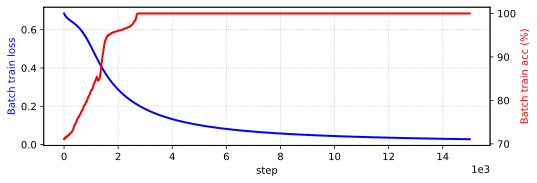

In [10]:
#| code-fold: true
fig, ax1 = plt.subplots(figsize=(8, 2.5))
ax2 = ax1.twinx()

ax1.plot(history["loss"], color="blue", linewidth=2)
ax2.plot(history["accs"], color="red",  linewidth=2)
ax1.set_xlabel("step")
ax1.ticklabel_format(axis="x", style="sci", scilimits=(3, 3))
ax1.grid(axis="both", linestyle="dotted", alpha=0.8)

ax1.set_ylabel("Batch train loss")
ax2.set_ylabel("Batch train acc (%)")
ax1.yaxis.label.set_color("blue")
ax2.yaxis.label.set_color("red");

:::{.callout-caution}
Note lower loss does not imply better accuracy, as the above graph shows. This is because accuracy is **threshold sensitive**. For example, we can have a model that has full accuracy but with low confidence (e.g. $[t, \ldots, t] + \delta_\mathbf{y}$ which is a probability vector around the threshold $t$ but perturbed just so the labels are correct). And we can have a more reasonable model that is not fully accurate but have high confidence in the true class whenever it's correct. The latter model will have lower accuracy but better cross-entropy.

:::

In [11]:
#| code-fold: true
import warnings
warnings.filterwarnings("ignore")

# transformations
with torch.no_grad():
    linear_0 = model[0](x0)
    linear_1 = model[0](x1)
    linear_act_0 = model[1](model[0](x0))
    linear_act_1 = model[1](model[0](x1))

    # separating hyperplane (see above discussion, i.e. w <- w1 - w0  == logistic reg)
    h = 1
    w, b = model[2].parameters()
    w, b = (w[h] - w[h-1]), (b[h] - b[h-1])

# plot
fig = plt.figure(figsize=(8, 3))
ax0 = fig.add_subplot(131)
ax1 = fig.add_subplot(132, projection="3d")
ax2 = fig.add_subplot(133, projection="3d")

ax0.grid(alpha=0.8, linestyle="dotted")
ax0.set_axisbelow(True)
ax0.scatter(x0[:, 0], x0[:, 1], s=2.0, label=0, color="C0")
ax0.scatter(x1[:, 0], x1[:, 1], s=2.0, label=1, color="C1")
ax0.set_xlabel("$x_1$")
ax0.set_ylabel("$x_2$")
ax0.set_xlim(-1.5, 1.5)
ax0.set_ylim(-1.5, 1.5)
ax0.set_title("(a) input")
ax0.legend()
ax0.set_facecolor("whitesmoke")
ax0.axis("equal")

ax1.scatter(linear_0[:, 0], linear_0[:, 1], linear_0[:, 2], s=3, label=0, color="C0", alpha=0.8)
ax1.scatter(linear_1[:, 0], linear_1[:, 1], linear_1[:, 2], s=3, label=1, color="C1", alpha=0.8)
ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
ax1.set_zlabel("$x_3$")
ax1.set_title("(b) linear")

ax2.scatter(linear_act_0[:, 0], linear_act_0[:, 1], linear_act_0[:, 2], s=3, label=0, color="C0")
ax2.scatter(linear_act_1[:, 0], linear_act_1[:, 1], linear_act_1[:, 2], s=3, label=1, color="C1")
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("$x_2$")
ax2.set_zlabel("$x_3$")
ax2.set_title("(c) linear + tanh")

# Generate grid of points
x_min = min(linear_act_1[:, 0].min(), linear_act_0[:, 0].min())
x_max = max(linear_act_1[:, 0].max(), linear_act_0[:, 0].max())
y_min = min(linear_act_1[:, 1].min(), linear_act_0[:, 1].min())
y_max = max(linear_act_1[:, 1].max(), linear_act_0[:, 1].max())
a, b, c, d = w[0], w[1], w[2], b
x = np.linspace(x_min, x_max, 50)
y = np.linspace(y_min, y_max, 50)
X, Y = np.meshgrid(x, y)
Z = (-a * X - b * Y - d) / c

# Plot the hyperplane for the positive class
ax2.plot_surface(X, Y, Z, alpha=0.5, color=f"C{h}")
fig.tight_layout();

Predicting on test data $\mathbb{R}^2$. Observe the nonlinear decision boundary:

In [12]:
# Create a grid of points
N = 300
x = np.linspace(-6, 6, N)
y = np.linspace(-5, 5, N)
X, Y = np.meshgrid(x, y)

# Calculate p[1] for each point in grid
inp = torch.tensor(list(zip(X, Y)), dtype=torch.float32).permute(0, 2, 1).reshape(-1, 2)
out = F.softmax(model(inp), dim=1)
Z = out[:, 1].reshape(300, 300).detach().numpy()

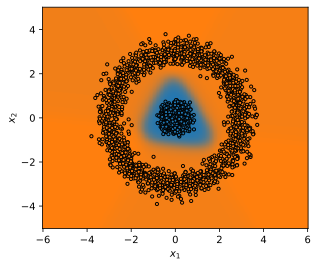

In [13]:
#| code-fold: true
# create a color plot
from matplotlib.colors import LinearSegmentedColormap

# Define custom colormap
colors = ["C0", "C1"]
n_bins = 100
cm = LinearSegmentedColormap.from_list(name="", colors=colors, N=n_bins)

fig = plt.figure(figsize=(6, 4))
plt.pcolormesh(X, Y, Z, shading="auto", cmap=cm, rasterized=True)
plt.scatter(x0[:, 0], x0[:, 1], s=10.0, label=0, color="C0", edgecolor="black")
plt.scatter(x1[:, 0], x1[:, 1], s=10.0, label=1, color="C1", edgecolor="black")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.gca().set_aspect("equal");

## Appendix: Universal approximation {#sec-univapprox}

[@Cybenko1989]. It turns out that any **continuous map** $f\colon \Omega \subset \mathbb{R}^d \to \mathbb{R}^m$ defined on a **compact set** $\Omega$ can be approximated by a 1-layer (wide) fully-connected network. Continuity on a compact domain is a reasonable assumption about a ground truth function that we assume exists. 

**Demo.** Approximating a one-dimensional curve with a ReLU network:

In [14]:
import torch

# Ground truth
x = torch.linspace(-2 * torch.pi, 2 * torch.pi, 1000)
y = torch.sin(x) + 0.3 * x

# Get sorted sample. Shifted for demo
B = sorted(torch.randint(30, 970, size=(24,)))
xs = x[B,]
ys = y[B,]

# ReLU approximation
z = torch.zeros(1000,) + ys[0]
for i in range(len(xs) - 1):
    if torch.isclose(xs[i + 1], xs[i]):
        m = torch.tensor(0.0)
    else:
        m = (ys[i+1] - ys[i]) / (xs[i+1] - xs[i])
    z += m * (torch.relu(x - xs[i]) - torch.relu(x - xs[i+1]))

**NOTE:** This only works for target $f$ with compact domain $[a, b]$ consistent with the theorem.

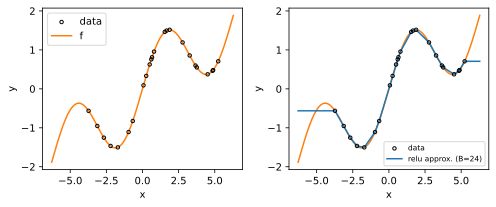

In [15]:
#| code-fold: true
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].scatter(xs, ys, facecolor="none", s=12, edgecolor="k", zorder=3, label="data")
ax[0].plot(x, y, color="C1", label="f")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].legend(loc="upper left")

ax[1].scatter(xs, ys, facecolor="none", s=12, edgecolor="k", zorder=4, label="data")
ax[1].plot(x, z, color="C0", label=f"relu approx. (B={len(B)})", zorder=3)
ax[1].plot(x, y, color="C1")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend(loc="lower right", fontsize=7.5)
fig.tight_layout();

:::{.callout-note}
You can see immediately that even functions (e.g. polynomial or trigonometric)
requires a large of nodes to approximate it with a 1-layer neural network, thereby making the network wide &mdash; the number of nodes depends on how "complex" the function is. The difficulty should scale exponentially[^exponential_univapprox] with input dimension $d.$ This motivates the need for **depth** in neural networks.

::: 

[^exponential_univapprox]: At each point in one axis, the same approximation is extended to another axes, and so on.

## Appendix: PyTorch tensors

### Tensors at the memory level

A PyTorch `Tensor` is a view over a contiguous block of typed memory — a `Storage` — plus metadata: **shape**, **stride**, **dtype**, and **device**. The tensors below share the same underlying storage, but with different stride interpretations (see below). This is why in-place operations on views can silently corrupt the graph: modifying `x` in-place affects `y`'s memory even though they appear to be different shapes:

In [16]:
import torch
from warnings import simplefilter
simplefilter("ignore", UserWarning)

x = torch.tensor([1.0, 2.0, 3.0])

# These ALL share memory:
y1 = x.view(3, 1)
y2 = x.reshape(3, 1)
y3 = x.T  # transpose
print(y1.storage().data_ptr() == x.storage().data_ptr())  # True
print(y2.storage().data_ptr() == x.storage().data_ptr())  # True
print(y3.storage().data_ptr() == x.storage().data_ptr())  # True

# This clearly does NOT share memory:
y4 = x.clone()
print(y4.storage().data_ptr() == x.storage().data_ptr())  # False

True
True
True
False


**Tensor stride.** This gives how many elements to skip in the underlying memory to move to the next position along a dimension. For the 1D case above, `stride=(1,)` means elements are contiguous — move 1 step in memory to get to the next element. For 2D tensors, stride has two values:

In [17]:
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0],
                  [7.0, 8.0, 9.0]])

y = x.T

print(x.stride())
print(y.stride())

# (3, 1) means:
#   - Skip 3 elements to move down one row
#   - Skip 1 element to move right one column

# (1, 3) means:
# when you transpose with `x.T` or use `.view`, it just reverses the stride.
# as shown above no new memory is allocated.

(3, 1)
(1, 3)


**The dtype matters for training.** Floating-point numbers work like [scientific notation in base 2]{.mark}: every value is stored as $\text{mantissa} \times 2^{\text{exponent}}$. The exponent sets the order of magnitude; the mantissa[^mantissa_decimal] provides the precision *within* that interval. Because the spacing between consecutive representable numbers scales with the exponent, the resolution is not uniform — near $1024$ the gap between adjacent values is around $10^{-4}$, while near $0.5$ the gap is around $10^{-7}$. Mental model: more significant digits, finer resolution.

Different dtypes allocate the 16 or 32 bits differently between exponent and mantissa:

| dtype | total bits | exponent bits | mantissa bits | decimal digits of precision | notes | recommended |
|---|---|---|---|---|---|---|
| `float32` | 32 | 8 | 23 | ~7 | standard training dtype | training from scratch |
| `float16` | 16 | 5 | 10 | ~3 | small exponent range — overflows above 65504 | older GPUs (V100) with loss scaling |
| `bfloat16` | 16 | 8 | 7 | ~2–3 | same exponent range as float32 — safe dynamic range | modern hardware (A100, H100, TPUs) |

Observe `float16` has only 5 exponent bits, which limits the range of representable values (up to ~65504). It also has only ~3 decimal digits of precision — enough to represent activations, but not enough to safely accumulate small gradient updates like $10^{-5}$, which can round to zero. `bfloat16` was designed to fix the range problem: it borrows bits from the mantissa to match `float32`'s 8-bit exponent. You give up a little precision, but you eliminate [overflow]{.underline} and [underflow]{.underline} during training. This tradeoff works well in practice because gradients don't need 7 digits of precision — they just need not to vanish. This will matter in training large models. For now, we use `float32` throughout.

[^mantissa_decimal]: A mantissa of 23 is ~7 decimal places. To see this write: $\log_{10} 2^{23} = 23 \log_{10} 2 \approx 6.92.$

In [18]:
torch.set_printoptions(precision=8)

def fmt(val, dtype):
    v = torch.tensor(val, dtype=dtype).item()
    return f"{v:.8e}"

dtypes = [
    (" float32", torch.float32),        # high precision, large range
    ("bfloat16", torch.bfloat16),       # low  precision, large range
    (" float16", torch.float16)         # low  precision, small range
]

cases = [
    ("precision", 1/3), 
    ("underflow", 1e-8), 
    ("overflow",  1e5)
]

header = f"{'  dtype':<10s} " + "  ".join(f" {title+' ('+f'{val:.0e}'+')':<18s}" for title, val in cases)
print(header)
print("-" * len(header))
for label, dtype in dtypes:
    row = f"{label:<10s} " + "  ".join(f" {fmt(val, dtype):<18s}" for _, val in cases)
    print(row)

  dtype     precision (3e-01)    underflow (1e-08)    overflow (1e+05)  
------------------------------------------------------------------------
 float32    3.33333343e-01       9.99999994e-09       1.00000000e+05    
bfloat16    3.33984375e-01       1.00117177e-08       9.98400000e+04    
 float16    3.33251953e-01       0.00000000e+00       inf               


### Tracking gradients with `requires_grad`

PyTorch implements [automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation) via a **computation graph** where nodes are tensors and edges are the operations that produced them. If `z` is a scalar output and `x` is a tensor that produced `z`, then `x.grad` gives $\frac{\partial \mathsf{z}}{\partial \mathsf{x}}$. Note that `x` has to have `requires_grad=True` set for this to work. Doing so means that every operation that involves `x` appends a new node to the graph, recording both the result and enough context to compute the local derivative. 

Here `x` is called a leaf node and its gradient is obtained by accumulating local gradients via the chain rule. This is discussed in excruciating detail [in here](/deep/03-autodiff.html). But you can see this in action in the following example:

In [19]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2          # y = x²
z = y + 3 * x       # z = x² + 3x

z.backward()        # Compute gradients
print(x.grad)       # dz/dx = ∂z/∂y * dy/dx + ∂z / ∂x
                    #       = 1 * 2x + 3 = 7 OR as a function of x:
                    # dz/dx = 2x + 3     = 7 evaluated at x=2.

tensor(7.)


Notice `grad_fn`. This is the handle to the computation graph. The tensor `z` knows it was produced by an addition, and that addition node knows its inputs. This chain reaches all the way back to `x`.


In [20]:
print(z.grad_fn)
print(z.grad_fn.next_functions)

((<PowBackward0 object at 0x1492b7820>, 0), (<MulBackward0 object at 0x1492b67d0>, 0))


:::{.callout-note}
Only leaf tensors accumulate gradients. If `x` is a *leaf* (you created it directly). `y` and `z` are *non-leaf* (computed from other tensors). After `.backward()`, only `x.grad` will be populated — not `y.grad` or `z.grad`. This is deliberate: storing gradients for every intermediate tensor in a deep network would be prohibitive. If you need a gradient for a non-leaf tensor, use `.retain_grad()` on it before the forward pass.[^leaf_retain]

:::

[^leaf_retain]: You can avoid this by using hooks instead to track gradients.

### Device

Every tensor lives on a specific **device** — either CPU memory or a GPU (e.g. `cuda:0`). Operations between tensors are only valid when both operands are on the **same device**; mixing devices raises a `RuntimeError` immediately. This is by design: there is no implicit data movement.

Moving a tensor across devices with `.to(device)` or `.cuda()` involves a **PCIe transfer** between host RAM and GPU VRAM (or vice-versa). Each transfer has latency (~10 μs overhead) and a throughput ceiling (~16 GB/s on PCIe 4.0). To maximize throughput in training loops, we have to minimize CPU-GPU synchronization:

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = model.to(device)
running_loss = torch.tensor(0.0, device=device) # <1>
log_interval = 100

for step, (x, y) in enumerate(train_loader):
    x, y = x.to(device), y.to(device) # <2>
    loss = F.cross_entropy(model(x), y)
    with torch.no_grad():
        running_loss += loss    # <3>

    if (step + 1) % log_interval == 0:
        avg = running_loss.item() / log_interval # <4>
        print(f"Step {step}: loss = {avg_loss:.4f}")
        running_loss.zero_()
```
1. Loss accumulator is defined on same device as loss tensor.
2. Model and data tensors are transferred to the same device.
3. Accumulating with `torch.no_grad` to not extend the computation graph.
4. Calling `running_loss.item()` forces a **CPU–GPU sync** (the CPU stalls until the current kernel finishes) which is necessary since the data has to be in the CPU to be printed. Keep running totals as [on-device tensors]{.underline} and call `.item()` only at spaced intervals.

## Appendix: Gradient check using PyTorch

Calculating manually the gradients of a 3-layer neural network:

In [21]:
# network parameters
w1 = torch.randn(16, 64, requires_grad=True)
w2 = torch.randn(64, 32, requires_grad=True)
w3 = torch.randn(32, 10, requires_grad=True)

# forward pass
B  = 8
x  = torch.randn(B, 16)
z1 = torch.relu(x @ w1)
z2 = torch.relu(z1 @ w2)
z3 = z2 @ w3

for u in [w1, w2, w3, z1, z2, z3]:
    u.retain_grad()

h = z3
y = torch.randint(0, 10, size=(B,))
loss = F.cross_entropy(h, y)
loss.backward()

Backward pass:

In [22]:
# walking down the trunk of the network
g3 = (F.softmax(h, dim=1) - F.one_hot(y, num_classes=10)) / B
g2 = g3 @ w3.T
g1 = (g2 * ((z1 @ w2) > 0).int()) @ w2.T

# branching to the leaf tensors (weights)
z0 = x
dw3 = z2.T @ g3
dw2 = z1.T @ (g2 * ((z1 @ w2) > 0).int())
dw1 = z0.T @ (g1 * ((z0 @ w1) > 0).int())

Note that shapes are equal, otherwise we can't subtract:

In [23]:
def compare(name, dt, t):
    exact  = torch.all(dt == t.grad).item()
    approx = torch.allclose(dt, t.grad, rtol=1e-5)
    max_diff = (dt - t.grad).abs().max().item()
    print(f'{name:<3s} | exact: {str(exact):5s} | approx: {str(approx):5s} | max_diff: {max_diff:.2e}')
    return max_diff

errors = []
errors.append(compare("z3", g3, z3))
errors.append(compare("z2", g2, z2))
errors.append(compare("z1", g1, z1))
errors.append(compare("w1", dw1, w1))
errors.append(compare("w2", dw2, w2))
errors.append(compare("w3", dw3, w3))
assert max(errors) < 1e-6, "Gradients do not match!"

z3  | exact: False | approx: True  | max_diff: 2.33e-10
z2  | exact: False | approx: True  | max_diff: 1.49e-08
z1  | exact: True  | approx: True  | max_diff: 0.00e+00
w1  | exact: True  | approx: True  | max_diff: 0.00e+00
w2  | exact: True  | approx: True  | max_diff: 0.00e+00
w3  | exact: False | approx: True  | max_diff: 1.49e-08
